Classifying Galaxy Mergers with CNNs and Domain Adaptation
---
<p align="center">
<img img src="https://github.com/AleksCipri/LSST_DSFP_DA/raw/main/major_challenges.png" alt="fine" width="400"/>
</p>

You've seen in the lectures how domain adaptation (DA) techniques can improve the generalization of neural networks (NNs) when the input data distribution changes between training and deployment. In this tutorial, you will get hands-on experience applying two DA methods to a real astrophysics problem.

We use the **DEEPMERGE** dataset: 15,426 simulated galaxy images from the Illustris simulation, rendered in HST/JWST filters (3 channels, 75×75 px). The binary classification task is **merger (1) vs. non-merger (0)**.

We treat **pristine** images (no noise) as the *source domain* $\mathcal{D}_s$ and **noisy** images (realistic observational noise) as the *target domain* $\mathcal{D}_t$. Your goal is to train a CNN that generalises from pristine to noisy images, using:

- **Baseline**: train on source only, evaluate on both
- **MMD**: Maximum Mean Discrepancy alignment of latent representations [[Paper]](https://www.jmlr.org/papers/volume13/gretton12a/gretton12a.pdf)
- **DANN**: Domain-Adversarial Neural Network with gradient reversal [[Paper]](https://arxiv.org/pdf/1505.07818)

For each model we report: training curves, confusion matrices, ROC curves, and a 2D t-SNE of the latent space for both domains.

##### Author: [Aleksandra Ciprijanovic](https://alexciprijanovic.com)

## Problem Setup

**Notation:**
- Source domain: $\mathcal{D}_s = \{(x_s^{(i)}, y_s^{(i)})\}_{i=1}^{N_s}$ — labelled pristine images, $y_s^{(i)} \in \{0, 1\}$
- Target domain: $\mathcal{D}_t = \{x_t^{(j)}\}_{j=1}^{N_t}$ — **unlabelled** noisy images
- We assume $p_s(y|x) = p_t(y|x)$ (same merger/non-merger structure) but $p_s(x) \neq p_t(x)$ (different noise levels)

**Neural network decomposition:**  
$f_\theta = g_\theta \circ \phi_\theta$, where $\phi_\theta$ is the feature extractor and $g_\theta$ is the classifier head.  
The **latent vector** $z = \phi_\theta(x) \in \mathbb{R}^{64}$ is what DA methods operate on.

**Classification loss:**
$$\mathcal{L}_{\text{CE}}(\theta) = -\frac{1}{N_s}\sum_{i=1}^{N_s} \log f_\theta^{(y_s^{(i)})}(x_s^{(i)})$$

**Before you start:** make a prediction — how large do you expect the source-to-target accuracy gap to be for the baseline model? Why might a model trained on pristine images fail on noisy ones even if the morphology is the same?

In [3]:
import numpy as np
from astropy.io import fits
from astropy.utils.data import download_file
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler
import os, random, copy
from tqdm import tqdm
from typing import Optional, List

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.autograd import Function

def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds()

## 1. Data

The DEEPMERGE dataset is hosted at the Mikulski Archive for Space Telescopes (MAST). We will download two versions:
- **pristine**: simulated observations *without* added noise (source domain $\mathcal{D}_s$)
- **noisy**: same images with realistic HST/JWST observational noise (target domain $\mathcal{D}_t$)

Each FITS file contains:
- Primary HDU: images of shape `(N, 3, 75, 75)` — three filter bands (F814W, F160W, F356W)
- Binary table extension: merger labels (0 = non-merger, 1 = merger)

In [4]:
BASE_URL = (
    'https://archive.stsci.edu/hlsps/deepmerge/'
    'hlsp_deepmerge_hst-jwst_acs-wfc3-nircam_illustris-z2_'
    'f814w-f160w-f356w_v1_sim-{}.fits'
)

def load_deepmerge(version):
    path = download_file(BASE_URL.format(version), cache=True, show_progress=True)
    with fits.open(path) as hdu:
        images = hdu[0].data.astype(np.float32)          # (N, 3, 75, 75)
        labels = hdu[1].data.field(0).astype(np.int64)   # 0 or 1
    images = images.transpose(0, 2, 3, 1)                # -> (N, 75, 75, 3) to correctly do ToTensor
    return images, labels

print('Loading pristine images (source domain)...')
X_src, y_src = load_deepmerge('pristine')
print(f'  shape={X_src.shape}  labels={dict(zip(*np.unique(y_src, return_counts=True)))}')

print('\nLoading noisy images (target domain)...')
X_tgt, y_tgt = load_deepmerge('noisy')
print(f'  shape={X_tgt.shape}  labels={dict(zip(*np.unique(y_tgt, return_counts=True)))}')

Loading pristine images (source domain)...
  shape=(15426, 75, 75, 3)  labels={np.int64(0): np.int64(7306), np.int64(1): np.int64(8120)}

Loading noisy images (target domain)...
  shape=(15426, 75, 75, 3)  labels={np.int64(0): np.int64(7306), np.int64(1): np.int64(8120)}


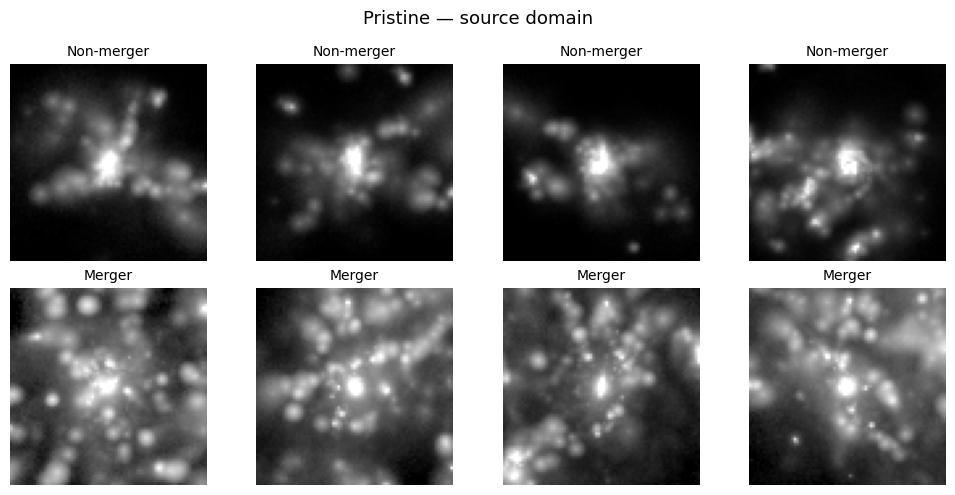

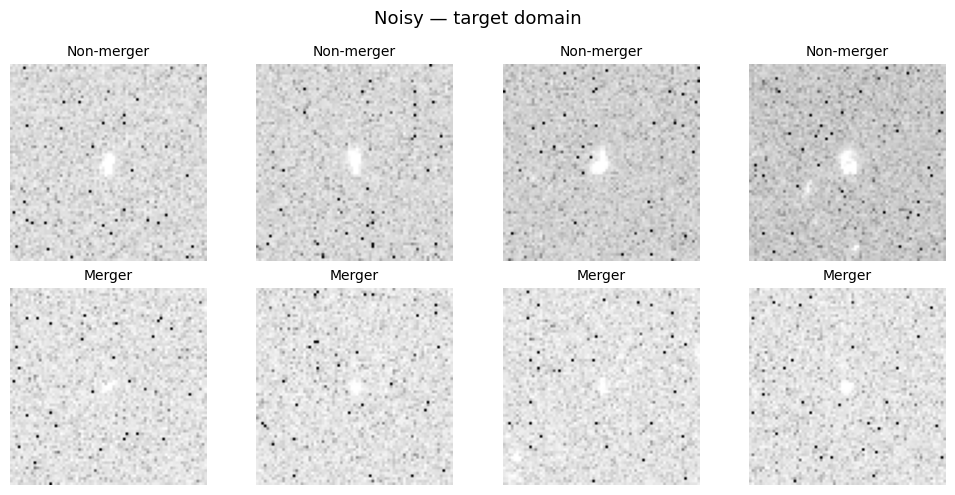

In [5]:
CLASS_NAMES = {0: 'Non-merger', 1: 'Merger'}

def show_examples(images, labels, title, n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class*2.5, 5))
    fig.suptitle(title, fontsize=13)
    for cls in [0, 1]:
        idxs = np.where(labels == cls)[0][:n_per_class]
        for j, i in enumerate(idxs):
            img = images[i, :, :, 0]  # first channel
            norm = simple_norm(img, 'log', percent=99)
            axes[cls, j].imshow(img, norm=norm, cmap='gray')
            axes[cls, j].axis('off')
            axes[cls, j].set_title(CLASS_NAMES[cls], fontsize=10)
    plt.tight_layout(); plt.show()

show_examples(X_src, y_src, 'Pristine — source domain')
show_examples(X_tgt, y_tgt, 'Noisy — target domain')

### Train / Validation / Test Split

We apply a **70 % train · 10 % validation · 20 % test** split independently to both domains, stratifying on the label so class balance is preserved.

In [6]:
RS = 42

def split_data(X, y):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, random_state=RS, stratify=y)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.667, random_state=RS, stratify=y_tmp)
    return X_tr, X_val, X_te, y_tr, y_val, y_te

X_s_tr, X_s_val, X_s_te, y_s_tr, y_s_val, y_s_te = split_data(X_src, y_src)
X_t_tr, X_t_val, X_t_te, y_t_tr, y_t_val, y_t_te = split_data(X_tgt, y_tgt)

print(f'Source  train={len(X_s_tr):5d}  val={len(X_s_val):4d}  test={len(X_s_te):4d}')
print(f'Target  train={len(X_t_tr):5d}  val={len(X_t_val):4d}  test={len(X_t_te):4d}')

Source  train=10798  val=1541  test=3087
Target  train=10798  val=1541  test=3087


### Normalisation & DataLoaders

We compute per-channel z-score statistics from each domain's *training* split and apply them consistently to val and test. The `transforms.Lambda` cast ensures images are `float32` before `ToTensor`.

> **Why do we normalise source and target separately?** Think about what each domain's pixel distribution looks like before answering.

In [7]:
def compute_stats(X):
    mean = X.mean(axis=(0,1,2))
    std  = X.std(axis=(0,1,2)) + 1e-8
    return tuple(float(v) for v in mean), tuple(float(v) for v in std)

src_mean, src_std = compute_stats(X_s_tr)
tgt_mean, tgt_std = compute_stats(X_t_tr)
print(f'Source  mean={tuple(f"{v:.4f}" for v in src_mean)}  '
      f'std={tuple(f"{v:.4f}" for v in src_std)}')
print(f'Target  mean={tuple(f"{v:.4f}" for v in tgt_mean)}  '
      f'std={tuple(f"{v:.4f}" for v in tgt_std)}')

class MergerDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images;  self.labels = labels;  self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

def make_transform(mean, std):
    return transforms.Compose([
        transforms.Lambda(lambda x: x.astype(np.float32)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

src_tfm = make_transform(src_mean, src_std)
tgt_tfm = make_transform(tgt_mean, tgt_std)
BATCH = 64

source_train_loader = DataLoader(MergerDataset(X_s_tr,  y_s_tr,  src_tfm), batch_size=BATCH, shuffle=True)
source_val_loader   = DataLoader(MergerDataset(X_s_val, y_s_val, src_tfm), batch_size=BATCH, shuffle=False)
source_test_loader  = DataLoader(MergerDataset(X_s_te,  y_s_te,  src_tfm), batch_size=BATCH, shuffle=False)
target_train_loader = DataLoader(MergerDataset(X_t_tr,  y_t_tr,  tgt_tfm), batch_size=BATCH, shuffle=True)
target_val_loader   = DataLoader(MergerDataset(X_t_val, y_t_val, tgt_tfm), batch_size=BATCH, shuffle=False)
target_test_loader  = DataLoader(MergerDataset(X_t_te,  y_t_te,  tgt_tfm), batch_size=BATCH, shuffle=False)

imgs, labs = next(iter(source_train_loader))
print(f'Batch shape: {imgs.shape}  dtype: {imgs.dtype}  labels: {labs[:8].tolist()}')

Source  mean=('0.0374', '0.0332', '0.0680')  std=('1.1533', '0.9101', '1.0990')
Target  mean=('0.0374', '0.0333', '0.0678')  std=('1.2269', '1.0603', '1.1758')
Batch shape: torch.Size([64, 3, 75, 75])  dtype: torch.float32  labels: [0, 1, 1, 0, 0, 1, 0, 1]


## 2. Model Architecture

We use a CNN with three convolutional blocks followed by two fully connected layers:

| Block | Layer | Filters / Units | Kernel | Other |
|-------|-------|-----------------|--------|-------|
| 1 | Conv2d | 8 | 5×5 | BatchNorm, ReLU, MaxPool(2), Dropout(0.1) |
| 2 | Conv2d | 16 | 3×3 | BatchNorm, ReLU, MaxPool(2), Dropout(0.1) |
| 3 | Conv2d | 32 | 3×3 | BatchNorm, ReLU, MaxPool(2), Dropout(0.2) |
| FC1 | Linear | 64 | — | ReLU — **this output is the latent vector $z$** |
| FC2 | Linear | 32 | — | ReLU |
| Out | Linear | 2 | — | (logits) |

After three MaxPool(2) layers: 75×75 → 37×37 → 18×18 → 9×9, so the flattened dimension is 32×9×9 = 2592.

**Questions to consider before writing the forward pass:**
- Why does the model need to return *both* logits *and* the latent vector $z$? When would you need one vs. the other?
- The latent vector $z$ is 64-dimensional. What are the trade-offs of making it larger or smaller for DA? Can alignment be performed on some other layer?

In [14]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 8, 5, padding=2), nn.BatchNorm2d(8),
            nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16),
            nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout2d(0.1),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2), nn.Dropout2d(0.2),
        )
        self.fc1 = nn.Sequential(nn.Linear(32 * 9 * 9, 64), nn.ReLU(inplace=True))
        self.fc2 = nn.Sequential(nn.Linear(64, 32), nn.ReLU(inplace=True))
        self.out = nn.Linear(32, num_classes)

    def forward(self, x):
        ## TO DO ##
        # 1. Pass x through block1, block2, block3 in sequence.
        # 2. Flatten x to shape (batch_size, 32*9*9) using x.view(x.size(0), -1).
        # 3. Pass through fc1 to obtain the 64-dim latent vector z.
        # 4. Pass z through fc2 and out to obtain logits.
        # 5. Return (logits, z) — both are needed: logits for classification, z for DA alignment.
        x = self.block3(self.block2(self.block1(x)))
        x = x.view(x.size(0), -1)
        z = self.fc1(x)
        logits = self.fc2(z)
        return logits, z
        

device = 'mps:0' #torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
_x = torch.randn(4, 3, 75, 75).to(device)
_logits, _z = CNN().to(device)(_x)
print(f'Logits: {_logits.shape}   Latent z: {_z.shape}')  # expect [4,2] and [4,64]

Device: mps:0
Logits: torch.Size([4, 32])   Latent z: torch.Size([4, 64])


## 3. Evaluation Functions

The helper functions below are provided. Read through them to understand what each one returns — you will interpret their outputs throughout the tutorial.

> **Note:** `get_predictions` returns `y_prob` as the softmax probability for the *merger* class (class 1). This is what the ROC curve and AUC are computed from.

In [16]:
def get_predictions(model, loader, device):
    """Returns (y_true, y_pred, y_prob, z_latent) for the full loader."""
    model.eval()
    y_true, y_pred, y_prob, z_all = [], [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits, z = model(imgs.to(device))
            probs = torch.softmax(logits, dim=1)[:, 1].cpu()
            preds = logits.argmax(1).cpu()
            y_true.extend(labels.tolist())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
            z_all.append(z.cpu())
    return (np.array(y_true), np.array(y_pred),
            np.array(y_prob), torch.cat(z_all, dim=0))


def plot_history(tl, vl, ta, va, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13)
    epochs = range(1, len(tl)+1)
    ax1.plot(epochs, tl, label='Train'); ax1.plot(epochs, vl, label='Val')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('CE Loss'); ax1.set_title('CE Loss'); ax1.legend()
    ax2.plot(epochs, ta, label='Train'); ax2.plot(epochs, va, label='Val')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)'); ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout(); plt.show()


def plot_conf_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    im = ax.imshow(cm, cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ticks = list(CLASS_NAMES.values())
    ax.set_xticks([0,1]); ax.set_xticklabels(ticks, fontsize=9)
    ax.set_yticks([0,1]); ax.set_yticklabels(ticks, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > thresh else 'black', fontsize=12)


def plot_roc_curve(y_true, y_prob, label, ax):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{label}  (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=0.8)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves'); ax.legend(fontsize=9)


def plot_tsne(z_src, ys, z_tgt, yt, title, ax, subset=600):
    from sklearn.manifold import TSNE
    z = torch.cat([z_src, z_tgt], dim=0)
    z = torch.tensor(StandardScaler().fit_transform(z.numpy()), dtype=torch.float32)
    domains = np.array(['source']*len(z_src) + ['target']*len(z_tgt))
    y = np.concatenate([ys, yt])
    rng = np.random.default_rng(42)
    idx = rng.choice(len(z), min(subset, len(z)), replace=False)
    z, y, domains = z[idx], y[idx], domains[idx]
    z_2d = TSNE(n_components=2, perplexity=100, random_state=42).fit_transform(z.numpy())
    cmap = plt.colormaps['tab10']
    for cls in [0, 1]:
        for dom, mk in [('source', 'o'), ('target', '^')]:
            mask = (y == cls) & (domains == dom)
            ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=[cmap(cls)], marker=mk,
                       s=15, alpha=0.7,
                       label=f"{CLASS_NAMES[cls]} ({'src' if dom=='source' else 'tgt'})")
    ax.set_title(title); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')


def full_eval(model, src_loader, tgt_loader, device, name):
    ys_t, ys_p, ys_prob, zs = get_predictions(model, src_loader, device)
    yt_t, yt_p, yt_prob, zt = get_predictions(model, tgt_loader, device)

    print(f'\n=== {name} ===')
    print(f'Source accuracy: {100*(ys_p==ys_t).mean():.2f}%')
    print(f'Target accuracy: {100*(yt_p==yt_t).mean():.2f}%')
    print('\nSource report:'); print(classification_report(ys_t, ys_p, target_names=list(CLASS_NAMES.values())))
    print('Target report:'); print(classification_report(yt_t, yt_p, target_names=list(CLASS_NAMES.values())))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f'{name} — Confusion Matrices', fontsize=12)
    plot_conf_matrix(ys_t, ys_p, 'Source (pristine) test', axes[0])
    plot_conf_matrix(yt_t, yt_p, 'Target (noisy) test',    axes[1])
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    plot_roc_curve(ys_t, ys_prob, 'Source (pristine)', ax)
    plot_roc_curve(yt_t, yt_prob, 'Target (noisy)',    ax)
    ax.set_title(f'{name} — ROC Curves')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    plot_tsne(zs, ys_t, zt, yt_t, f'{name} — Latent Space (t-SNE)', ax)
    ax.legend(markerscale=1.5, fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout(); plt.show()

    return ys_t, ys_p, ys_prob, yt_t, yt_p, yt_prob

## 4. Baseline: Cross-Entropy Only (No Domain Adaptation)

We first train the CNN on the pristine (source) training set for 20 epochs using only the cross-entropy loss, then evaluate on both source and target test sets.

This establishes the **performance gap** — the drop in accuracy when moving from pristine to noisy images. The gap is your target to close with DA.

**Your task:** fill in the two lines inside the training loop that perform the forward pass and compute the loss. Everything else — the val loop, logging, and best-model saving — is provided.

In [17]:
NUM_EPOCHS = 20
CE_model  = CNN(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(CE_model.parameters(), lr=1e-3)

tl_ce, vl_ce, ta_ce, va_ce = [], [], [], []
best_val, best_state_ce = float('inf'), None

for epoch in tqdm(range(NUM_EPOCHS)):
    CE_model.train()
    t_loss = t_correct = t_total = 0

    for imgs, labels in source_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        ## TO DO ##
        # Forward pass: call CE_model on imgs to get (logits, _).
        # Compute the cross-entropy loss using criterion.
        (logits, _) = CE_model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss    += loss.item()
        t_correct += logits.argmax(1).eq(labels).sum().item()
        t_total   += labels.size(0)

    CE_model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in source_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _  = CE_model(imgs)
            v_loss    += criterion(logits, labels).item()
            v_correct += logits.argmax(1).eq(labels).sum().item()
            v_total   += labels.size(0)

    tl = t_loss / len(source_train_loader)  # train CE loss
    vl = v_loss / len(source_val_loader)    # val CE loss
    ta = 100 * t_correct / t_total
    va = 100 * v_correct / v_total

    tl_ce.append(tl); vl_ce.append(vl)
    ta_ce.append(ta); va_ce.append(va)

    if vl < best_val:
        best_val = vl; best_state_ce = copy.deepcopy(CE_model.state_dict())
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}  CE={tl:.4f}  val_CE={vl:.4f}  '
              f'train_acc={ta:.1f}%  val_acc={va:.1f}%')

 25%|██████████▊                                | 5/20 [00:12<00:35,  2.34s/it]

Epoch   5  CE=0.5377  val_CE=0.5138  train_acc=74.3%  val_acc=75.4%


 50%|█████████████████████                     | 10/20 [00:23<00:23,  2.31s/it]

Epoch  10  CE=0.4731  val_CE=0.5271  train_acc=77.4%  val_acc=74.2%


 75%|███████████████████████████████▌          | 15/20 [00:35<00:11,  2.34s/it]

Epoch  15  CE=0.4418  val_CE=0.4947  train_acc=79.1%  val_acc=76.9%


100%|██████████████████████████████████████████| 20/20 [00:48<00:00,  2.42s/it]

Epoch  20  CE=0.4286  val_CE=0.4898  train_acc=80.3%  val_acc=76.6%


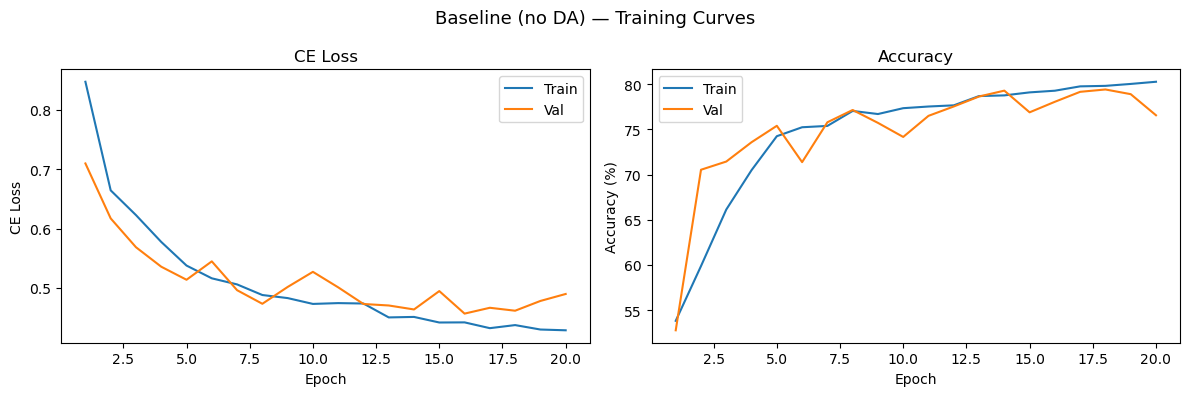


=== Baseline (no DA) ===
Source accuracy: 76.71%
Target accuracy: 64.17%

Source report:
              precision    recall  f1-score   support

  Non-merger       0.71      0.87      0.78      1462
      Merger       0.85      0.67      0.75      1625

    accuracy                           0.77      3087
   macro avg       0.78      0.77      0.77      3087
weighted avg       0.78      0.77      0.77      3087

Target report:
              precision    recall  f1-score   support

  Non-merger       0.58      0.92      0.71      1462
      Merger       0.85      0.39      0.53      1625

    accuracy                           0.64      3087
   macro avg       0.71      0.66      0.62      3087
weighted avg       0.72      0.64      0.62      3087



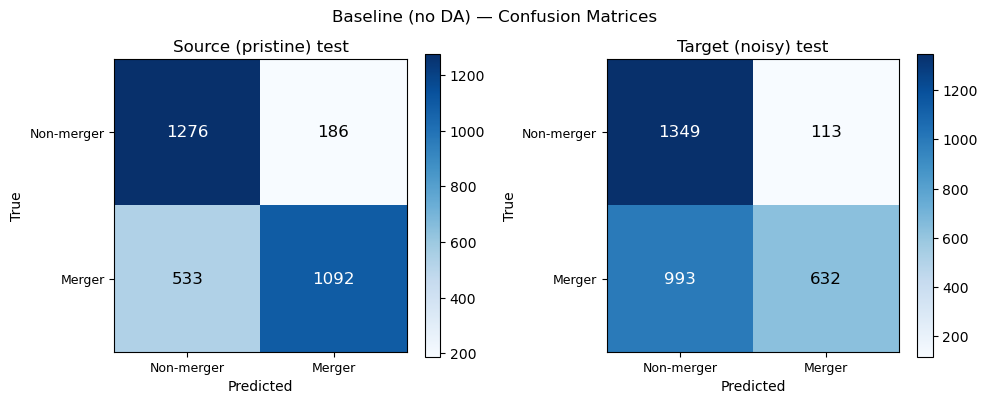

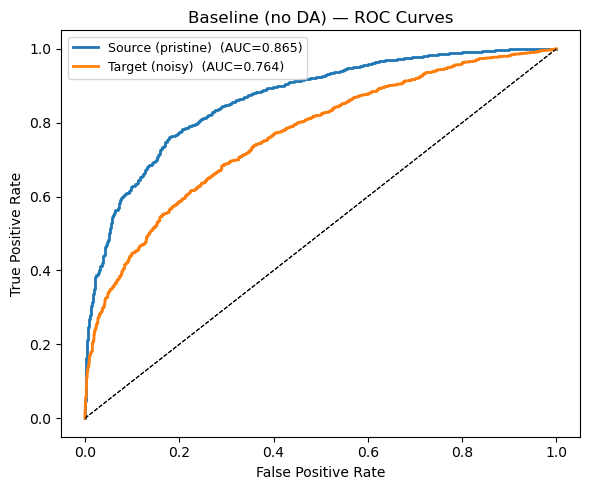

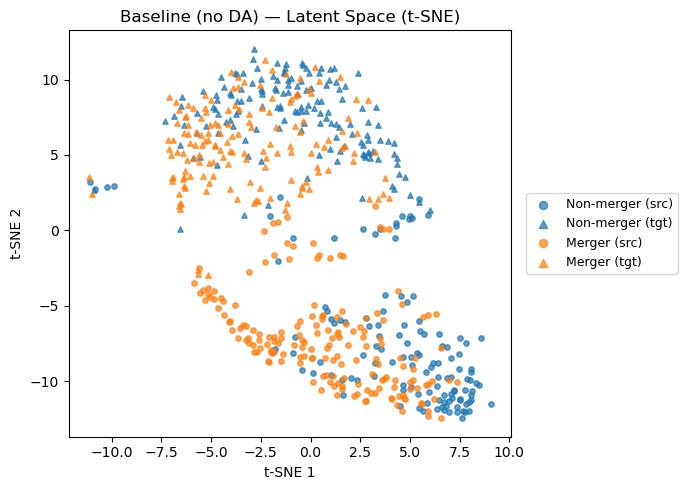

In [18]:
plot_history(tl_ce, vl_ce, ta_ce, va_ce, 'Baseline (no DA) — Training Curves')
CE_model.load_state_dict(best_state_ce)
res_ce_s_t, res_ce_s_p, res_ce_s_prob, res_ce_t_t, res_ce_t_p, res_ce_t_prob = \
    full_eval(CE_model, source_test_loader, target_test_loader, device, 'Baseline (no DA)')

### Reflection

Look at the source and target accuracy numbers and the t-SNE plot.

- How large is the accuracy gap? Does it match your prediction?
- In the t-SNE, are source and target points for the same class clustered together, or separated? What does this tell you about the features the model has learned?
- The model has never seen a noisy image during training. Why does it still get *some* of them right?

## 5. MMD Domain Adaptation

<p align="center">
<img img src="https://github.com/AleksCipri/LSST_DSFP_DA/raw/main/mmd.png" alt="fine" width="400"/>
</p>

We add a **Maximum Mean Discrepancy** (MMD) penalty that encourages the source and target latent distributions to overlap:

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda_{\text{MMD}} \cdot \mathcal{L}_{\text{MMD}}$$

The MMD² between two distributions $\mathbb{P}_s$ and $\mathbb{P}_t$ with RBF kernel $k(z, z') = \exp\!\left(-\frac{\|z-z'\|^2}{2\sigma^2}\right)$ is:

$$\mathcal{L}_{\text{MMD}} = \mathbb{E}_{z,z' \sim \mathbb{P}_s}[k(z,z')] + \mathbb{E}_{\tilde{z},\tilde{z}' \sim \mathbb{P}_t}[k(\tilde{z},\tilde{z}')] - 2\,\mathbb{E}_{z \sim \mathbb{P}_s,\,\tilde{z} \sim \mathbb{P}_t}[k(z,\tilde{z})]$$

We use a mixture of RBF kernels with bandwidths $\sigma \in \{1, 5, 10, 50\}$ to capture structure at multiple scales. **Target labels are never used.**

**Questions to consider:**
- What does MMD² = 0 mean geometrically in the latent space?
- We compute MMD on 64-dimensional latent vectors $z$, not on 75×75×3 pixel tensors. Why is this a better choice?
- What happens if $\lambda_{\text{MMD}}$ is too large? What if it is too small?

In [23]:
def _rbf_kernel(x: torch.Tensor, y: torch.Tensor, sigma: float) -> torch.Tensor:
    x_sq = x.pow(2).sum(1, keepdim=True)
    y_sq = y.pow(2).sum(1, keepdim=True)
    # clamp prevents small negative values from floating-point cancellation
    # amplifying via exp with small sigma, which would produce NaN losses
    dist = torch.clamp(x_sq + y_sq.t() - 2.0 * x @ y.t(), min=0.0)
    return torch.exp(-dist / (2.0 * sigma ** 2))


class MMDLoss(nn.Module):
    """
    Unbiased MMD² with a mixture of RBF kernels.
    sigmas : kernel bandwidths — multiple scales capture structure at different resolutions.
    """
    def __init__(self, sigmas: Optional[List[float]] = None):
        super().__init__()
        self.sigmas = sigmas or [1.0, 5.0, 10.0, 50.0]

    def forward(self, source: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        ## TO DO ##
        # For each sigma in self.sigmas, compute k_ss, k_tt, k_st using _rbf_kernel,
        # take the mean of each, and accumulate: mmd += k_ss.mean() + k_tt.mean() - 2*k_st.mean()
        # Initialise mmd = torch.tensor(0.0, device=source.device) before the loop.
        # Return mmd.
        mmd = torch.tensor(0.0, device=source.device)
        for sig in self.sigmas:
            k_ss = _rbf_kernel(source,source,sig)
            k_tt = _rbf_kernel(target,target,sig)
            k_st = _rbf_kernel(source,target,sig)
            mmd += k_ss.mean() + k_tt.mean() - 2*k_st.mean()
        return mmd

### MMD Training Loop

The key difference from the baseline: **both source and target batches are passed through the model together** in each step. We use the latent vectors to compute the MMD penalty, but only the source logits for the classification loss.

**Your tasks** (marked with `## TO DO ##`):
1. Concatenate source and target image batches along the batch dimension.
2. Run the combined batch through the model to get `logits` and `z`.
3. Split `logits` and `z` back into source and target portions.
4. Compute `ce_loss` (source only) and `mmd_loss` (source vs. target latents), then combine.

In [33]:
MMD_model   = CNN(num_classes=2).to(device)
criterion   = nn.CrossEntropyLoss()
optimizer   = optim.Adam(MMD_model.parameters(), lr=1e-3)
mmd_loss_fn = MMDLoss()
lambda_mmd  = 0.2

tl_mmd, vl_mmd, ta_mmd, va_mmd, mmd_losses = [], [], [], [], []
best_val_m, best_state_m = float('inf'), None

for epoch in tqdm(range(NUM_EPOCHS)):
    MMD_model.train()
    t_ce = t_da = t_correct = t_total = 0
    tgt_iter = iter(target_train_loader)

    for imgs_s, labels_s in source_train_loader:
        try:    imgs_t, _ = next(tgt_iter)
        except: tgt_iter = iter(target_train_loader); imgs_t, _ = next(tgt_iter)
        imgs_s, labels_s = imgs_s.to(device), labels_s.to(device)
        imgs_t = imgs_t.to(device)

        ## TO DO ##
        # 1. Concatenate imgs_s and imgs_t into a single tensor `combined`, so both domains
        #    pass through the model in one forward pass.
        #
        # 2. Run the combined batch through MMD_model to obtain class logits and
        #    the latent feature vector z for every image.
        #
        # 3. Split z and logits back into their source and target portions using
        #    the known source batch size as the boundary index.
        #
        # 4. Compute the classification loss on source logits and labels.
        #    Compute the MMD loss between source and target latent features.
        #    Combine them into a single scalar using lambda_mmd as the trade-off weight.
        combined = torch.cat([imgs_s,imgs_t])
        size = imgs_s.shape[0]
        logits, z = MMD_model(combined)
        logits_s = logits[:size]
        logits_t = logits[size:]
        z_s = z[:size]
        z_t = z[size:]
        ce_loss = criterion(logits_s,labels_s)
        mmd_loss = mmd_loss_fn(z_s,z_t)
        loss = ce_loss + lambda_mmd*mmd_loss

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_ce      += ce_loss.item()
        t_da      += mmd_loss.item()
        t_correct += logits_s.argmax(1).eq(labels_s).sum().item()
        t_total   += labels_s.size(0)

    # --- val ---
    MMD_model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in source_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _  = MMD_model(imgs)
            v_loss    += criterion(logits, labels).item()
            v_correct += logits.argmax(1).eq(labels).sum().item()
            v_total   += labels.size(0)

    n   = len(source_train_loader)
    tl  = t_ce / n                          # train CE loss
    vl  = v_loss / len(source_val_loader)   # val CE loss
    ta  = 100 * t_correct / t_total
    va  = 100 * v_correct / v_total
    mmd = t_da / n                          # MMD loss (logged separately)

    tl_mmd.append(tl); vl_mmd.append(vl)
    ta_mmd.append(ta); va_mmd.append(va)
    mmd_losses.append(mmd)

    if vl < best_val_m:
        best_val_m = vl; best_state_m = copy.deepcopy(MMD_model.state_dict())
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}  CE={tl:.4f}  MMD={mmd:.4f}  '
              f'val_CE={vl:.4f}  train_acc={ta:.1f}%  val_acc={va:.1f}%')

 25%|██████████▊                                | 5/20 [00:24<01:12,  4.86s/it]

Epoch   5  CE=0.6109  MMD=0.0728  val_CE=0.5640  train_acc=67.0%  val_acc=72.6%


 50%|█████████████████████                     | 10/20 [00:48<00:48,  4.85s/it]

Epoch  10  CE=0.5056  MMD=0.0802  val_CE=0.4959  train_acc=75.6%  val_acc=76.8%


 75%|███████████████████████████████▌          | 15/20 [01:13<00:24,  4.88s/it]

Epoch  15  CE=0.4665  MMD=0.0779  val_CE=0.4919  train_acc=77.8%  val_acc=75.7%


100%|██████████████████████████████████████████| 20/20 [01:37<00:00,  4.89s/it]

Epoch  20  CE=0.4426  MMD=0.0752  val_CE=0.4740  train_acc=79.7%  val_acc=76.4%


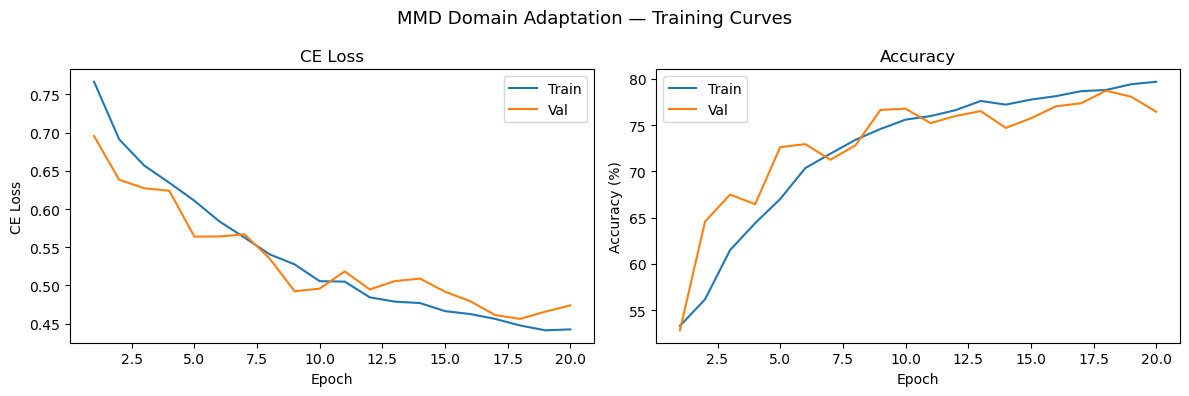

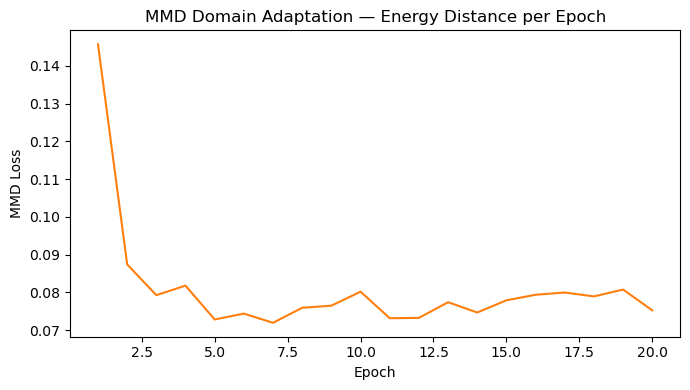


=== MMD Domain Adaptation ===
Source accuracy: 78.85%
Target accuracy: 71.98%

Source report:
              precision    recall  f1-score   support

  Non-merger       0.77      0.80      0.78      1462
      Merger       0.81      0.78      0.80      1625

    accuracy                           0.79      3087
   macro avg       0.79      0.79      0.79      3087
weighted avg       0.79      0.79      0.79      3087

Target report:
              precision    recall  f1-score   support

  Non-merger       0.70      0.71      0.71      1462
      Merger       0.74      0.72      0.73      1625

    accuracy                           0.72      3087
   macro avg       0.72      0.72      0.72      3087
weighted avg       0.72      0.72      0.72      3087



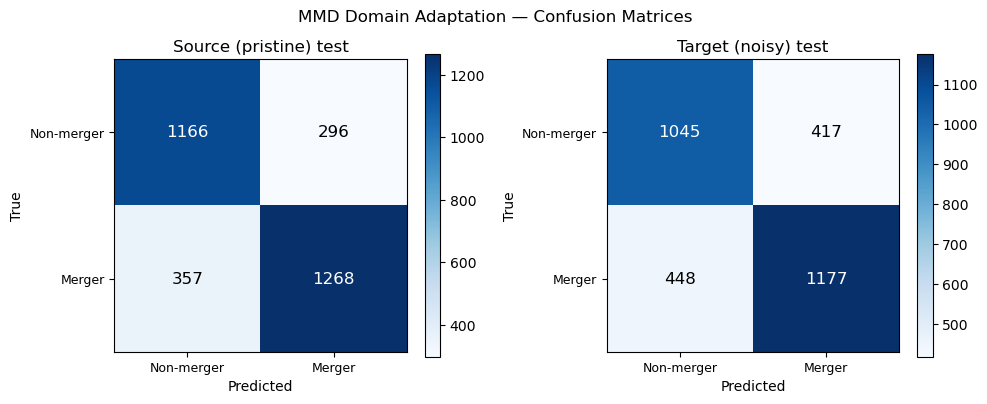

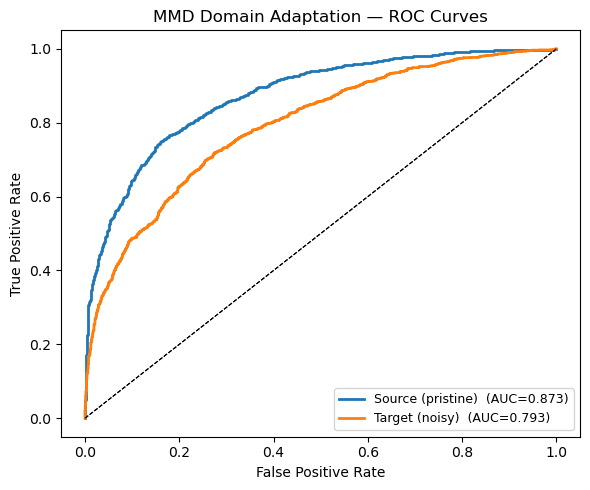

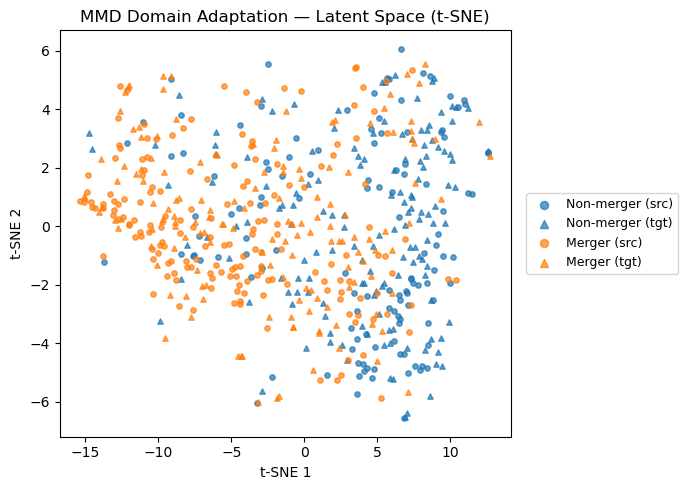

In [34]:
plot_history(tl_mmd, vl_mmd, ta_mmd, va_mmd, 'MMD Domain Adaptation — Training Curves')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(mmd_losses)+1), mmd_losses, color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('MMD Loss')
ax.set_title('MMD Domain Adaptation — Energy Distance per Epoch')
plt.tight_layout(); plt.show()

MMD_model.load_state_dict(best_state_m)
res_mmd_s_t, res_mmd_s_p, res_mmd_s_prob, res_mmd_t_t, res_mmd_t_p, res_mmd_t_prob = \
    full_eval(MMD_model, source_test_loader, target_test_loader, device, 'MMD Domain Adaptation')

### Reflection

- Look at the MMD² curve. Is it decreasing? What does a decreasing MMD² mean for the latent space?
- Compare the t-SNE before and after MMD. Do source and target points of the same class overlap more?
- Did target accuracy improve? Did source accuracy stay stable, or did it drop? If it dropped, why might that happen?
- **Potential pitfall:** if you set `lambda_mmd` very large (e.g. 10), what do you expect would happen to the CE loss and classification accuracy? Try it!

## 6. Domain-Adversarial Neural Network (DANN)

<p align="center">
<img img src="https://adapt-python.github.io/adapt/_images/dann.png" alt="fine" width="600"/>
</p>

In DANN, a **domain classifier** $G_d$ tries to distinguish source from target latents. A **gradient reversal layer (GRL)** flips the sign of gradients flowing *back* through it, so the feature extractor learns to *fool* the domain classifier — forcing it to produce domain-invariant representations.

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \cdot \mathcal{L}_{\text{domain}}$$

The domain classifier minimises $\mathcal{L}_{\text{domain}}$ (binary cross-entropy: source=1, target=0). The feature extractor *maximises* it via the GRL.

**Questions to consider before training:**
- At the adversarial optimum, the domain classifier is at chance (50% accuracy). What value does $\mathcal{L}_{\text{domain}}$ converge to for binary cross-entropy at 50% accuracy? *(Hint: $-\log(0.5)$)*
- Should the domain loss **increase** or **decrease** during training as DA improves?
- What could go wrong if $\lambda$ is too large early in training, before the feature extractor has learned anything useful?
- What could go wrong if the domain classifier is much more powerful than the feature extractor?

In [39]:
class GradientReversal(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)   # identity in the forward pass

    @staticmethod
    def backward(ctx, grad):
        ## TO DO ##
        # Return the negated, scaled gradient for x, and None for lam.
        # The gradient reversal is: -lam * grad.
        # This single line is the entire mechanism that makes DANN adversarial.
        return -ctx.lam * grad, None

def grad_reverse(x, lam=1.0): # the scaling of the DA loss is basically done using lam
    return GradientReversal.apply(x, lam)


class DomainClassifier(nn.Module):
    def __init__(self, z_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 32), nn.ReLU(),
            nn.Linear(32, 1),   # single logit — used with BCEWithLogitsLoss
        )
    def forward(self, z, lam=1.0):
        return self.net(grad_reverse(z, lam))

### DANN Training Loop

**Your tasks** (marked with `## TO DO ##`):
1. Build `dom_labels`: a column vector of ones for source images and zeros for target images.
2. Concatenate source and target batches and run through `DANN_model`.
3. Split logits and `z` into source and target portions.
4. Compute `loss_ce` (source classification) and `loss_dom` (domain classification via the `domain_clf`), then combine.

In [44]:
DANN_model  = CNN(num_classes=2).to(device)
domain_clf  = DomainClassifier(z_dim=64).to(device)
optimizer_d = optim.Adam(
    list(DANN_model.parameters()) + list(domain_clf.parameters()), lr=1e-3)
criterion_ce  = nn.CrossEntropyLoss()
criterion_dom = nn.BCEWithLogitsLoss()
lambda_grl    = 0.25

tl_d, vl_d, ta_d, va_d, dom_losses = [], [], [], [], []
best_val_d, best_state_d = float('inf'), None

for epoch in tqdm(range(NUM_EPOCHS)):
    DANN_model.train(); domain_clf.train()
    t_ce = t_da = t_correct = t_total = 0
    tgt_iter = iter(target_train_loader)

    for imgs_s, labels_s in source_train_loader:
        try:    imgs_t, _ = next(tgt_iter)
        except: tgt_iter = iter(target_train_loader); imgs_t, _ = next(tgt_iter)
        imgs_s, labels_s = imgs_s.to(device), labels_s.to(device)
        imgs_t = imgs_t.to(device)

        ## TO DO ##
        # 1. Create domain labels: a float tensor of 1s for source images and 0s for target
        #    images, shaped (batch_size, 1) each, then concatenate them into a single tensor
        #    on the correct device.
        #
        # 2. Concatenate source and target images along the batch dimension, then pass the
        #    combined batch through DANN_model to get logits and latent features z.
        #
        # 3. Slice out only the source portion of logits (first imgs_s.size(0) rows)
        #    for the classification loss.
        #
        # 4. Compute the classification loss on source logits vs source labels.
        #    Compute the domain loss by passing z through the domain classifier (with
        #    gradient reversal applied via lambda_grl) against the domain labels.
        #    Sum both losses into a single scalar representing the total loss.
        dom_labels = torch.ones(imgs_s.size(0),1)
        tar_labels = torch.zeros(imgs_s.size(0),1)
        comb_labels = torch.cat([dom_labels,tar_labels]).to(device)
        comb_imgs = torch.cat([imgs_s,imgs_t])
        logits, z = DANN_model(comb_imgs)
        logits_s = logits[:imgs_s.size(0)]
        loss_ce = criterion_ce(logits_s,labels_s)
        loss_dom = criterion_dom(domain_clf(z,lam=lambda_grl),comb_labels)
        loss = loss_ce + loss_dom

        optimizer_d.zero_grad(); loss.backward(); optimizer_d.step()
        t_ce      += loss_ce.item()
        t_da      += loss_dom.item()
        t_correct += logits_s.argmax(1).eq(labels_s).sum().item()
        t_total   += labels_s.size(0)

    # --- val ---
    DANN_model.eval()
    v_loss = v_correct = v_total = 0
    with torch.no_grad():
        for imgs, labels in source_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _  = DANN_model(imgs)
            v_loss    += criterion_ce(logits, labels).item()
            v_correct += logits.argmax(1).eq(labels).sum().item()
            v_total   += labels.size(0)

    n   = len(source_train_loader)
    tl  = t_ce / n                          # train CE loss
    vl  = v_loss / len(source_val_loader)   # val CE loss
    ta  = 100 * t_correct / t_total
    va  = 100 * v_correct / v_total
    dom = t_da / n                          # domain loss (logged separately)

    tl_d.append(tl); vl_d.append(vl)
    ta_d.append(ta); va_d.append(va)
    dom_losses.append(dom)

    if vl < best_val_d:
        best_val_d = vl; best_state_d = copy.deepcopy(DANN_model.state_dict())
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}  CE={tl:.4f}  DOM={dom:.4f}  '
              f'val_CE={vl:.4f}  train_acc={ta:.1f}%  val_acc={va:.1f}%')

 25%|██████████▊                                | 5/20 [00:22<01:04,  4.31s/it]

Epoch   5  CE=0.6895  DOM=0.5797  val_CE=0.6897  train_acc=57.5%  val_acc=60.7%


 50%|█████████████████████                     | 10/20 [00:43<00:42,  4.29s/it]

Epoch  10  CE=0.6056  DOM=0.6893  val_CE=0.5939  train_acc=68.3%  val_acc=70.2%


 75%|███████████████████████████████▌          | 15/20 [01:06<00:22,  4.44s/it]

Epoch  15  CE=0.5544  DOM=0.6946  val_CE=0.5302  train_acc=72.4%  val_acc=74.5%


100%|██████████████████████████████████████████| 20/20 [01:27<00:00,  4.38s/it]

Epoch  20  CE=0.5081  DOM=0.6942  val_CE=0.5151  train_acc=75.8%  val_acc=75.5%


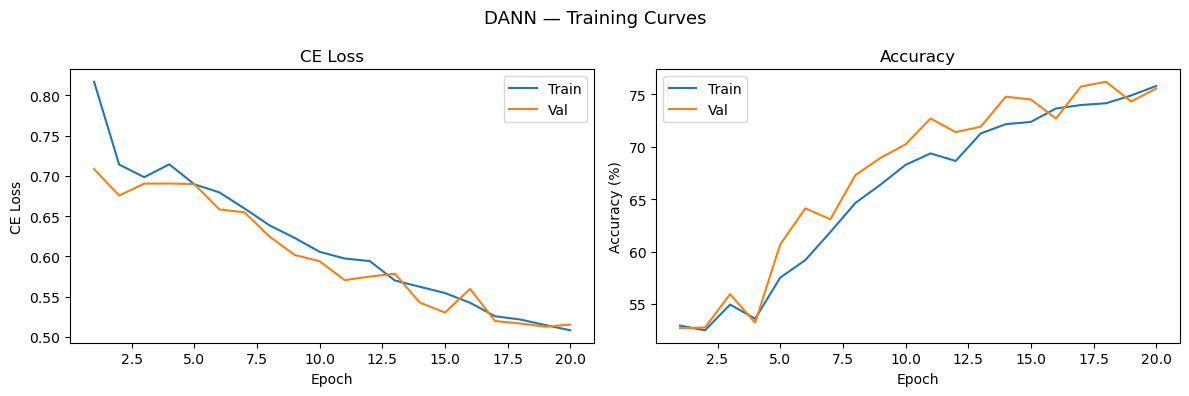

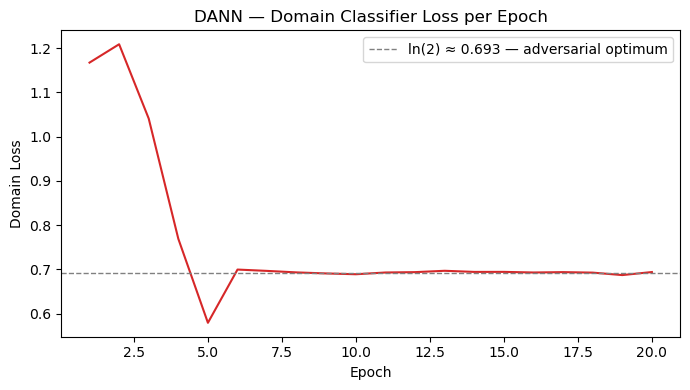


=== DANN ===
Source accuracy: 75.77%
Target accuracy: 70.65%

Source report:
              precision    recall  f1-score   support

  Non-merger       0.73      0.78      0.75      1462
      Merger       0.79      0.74      0.76      1625

    accuracy                           0.76      3087
   macro avg       0.76      0.76      0.76      3087
weighted avg       0.76      0.76      0.76      3087

Target report:
              precision    recall  f1-score   support

  Non-merger       0.71      0.64      0.67      1462
      Merger       0.70      0.77      0.73      1625

    accuracy                           0.71      3087
   macro avg       0.71      0.70      0.70      3087
weighted avg       0.71      0.71      0.71      3087



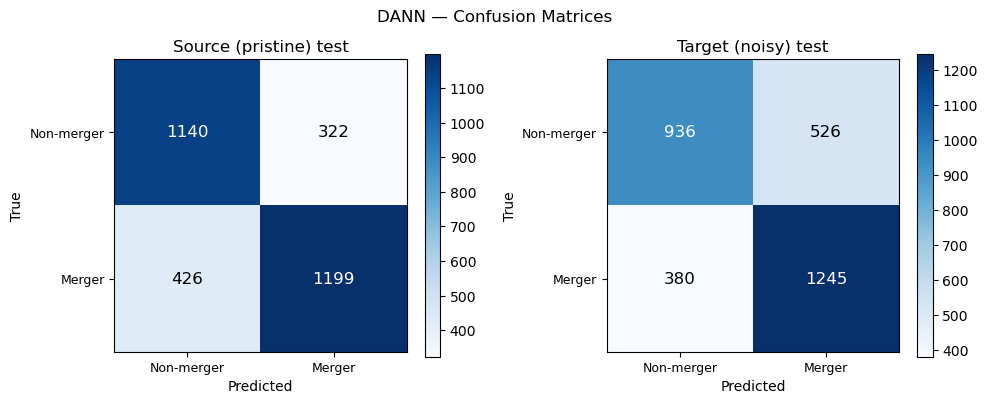

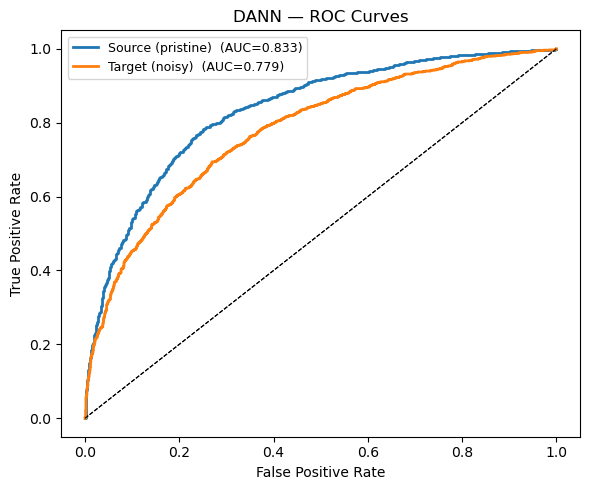

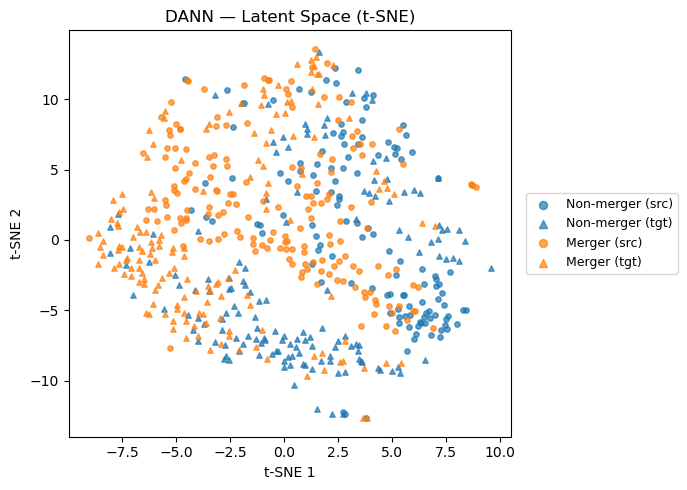

In [47]:
plot_history(tl_d, vl_d, ta_d, va_d, 'DANN — Training Curves')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(dom_losses)+1), dom_losses, color='tab:red')
ax.axhline(y=0.693, color='gray', linestyle='--', lw=1,
           label='ln(2) \u2248 0.693 \u2014 adversarial optimum')
ax.legend(loc='upper right')
ax.set_xlabel('Epoch'); ax.set_ylabel('Domain Loss')
ax.set_title('DANN — Domain Classifier Loss per Epoch')
ax.legend(); plt.tight_layout(); plt.show()

DANN_model.load_state_dict(best_state_d)
res_d_s_t, res_d_s_p, res_d_s_prob, res_d_t_t, res_d_t_p, res_d_t_prob = \
    full_eval(DANN_model, source_test_loader, target_test_loader, device, 'DANN')

### Reflection

- The dashed line marks $\ln(2) \approx 0.693$ — the binary cross-entropy at 50% accuracy (random guessing). Is the domain loss approaching this value? If it stays well below, what does that mean?
- Compare the DANN t-SNE to the MMD t-SNE. Which method produced better-aligned latent clusters?
- DANN requires tuning two things: `lambda_grl` and the domain classifier capacity. How might a too-powerful domain classifier prevent adaptation?

## 7. Common Training Difficulties and Pitfalls

Both MMD and DANN can fail silently — the training loss decreases but target accuracy does not improve. Here are the most common failure modes:

**MMD**
- **$\lambda_{\text{MMD}}$ too large**: the model prioritises alignment over classification. The CE loss stops decreasing and source accuracy collapses. The MMD² goes to zero quickly but the classifier is useless.
- **$\lambda_{\text{MMD}}$ too small**: alignment is negligible. The model behaves like the baseline.
- **Kernel bandwidth mismatch**: if all $\sigma$ values are much smaller than the typical pairwise distances in the latent space, all kernel values are near zero and the gradient signal vanishes. The clamping in `_rbf_kernel` guards against NaN but not against zero-gradient.
- **Negative transfer**: forcing alignment can hurt if the source and target tasks are not truly aligned (e.g. class imbalance between domains).

**DANN**
- **Domain classifier too strong early**: if the domain classifier converges faster than the feature extractor, it provides a vanishing gradient signal — the GRL reversal of a near-zero gradient does nothing.
- **$\lambda_{\text{GRL}}$ too large**: catastrophic forgetting — the feature extractor destroys classification-relevant features in its rush to fool the domain classifier.
- **Domain loss does not rise toward $\ln(2)$**: the adversarial game has not reached equilibrium. Either the domain classifier is winning (loss stays low) or the feature extractor collapsed (both losses are noisy).
- **Gradient instability**: because the GRL flips signs, loss curves can be jagged. Gradient clipping (`torch.nn.utils.clip_grad_norm_`) can help.

**General**
- **Forgetting to use the validation set for model selection**: saving the best checkpoint by *training* loss can overfit; always select on validation CE loss.
- **Normalising source and target together**: leaks target statistics into training. Always compute normalisation statistics from the source training split only, or separately per domain.
- **Class imbalance**: if the merger/non-merger ratio differs between source and target, MMD and DANN may align the wrong distributions.

## 8. Model Comparison

Side-by-side ROC curves and a summary accuracy / AUC table for all three models.

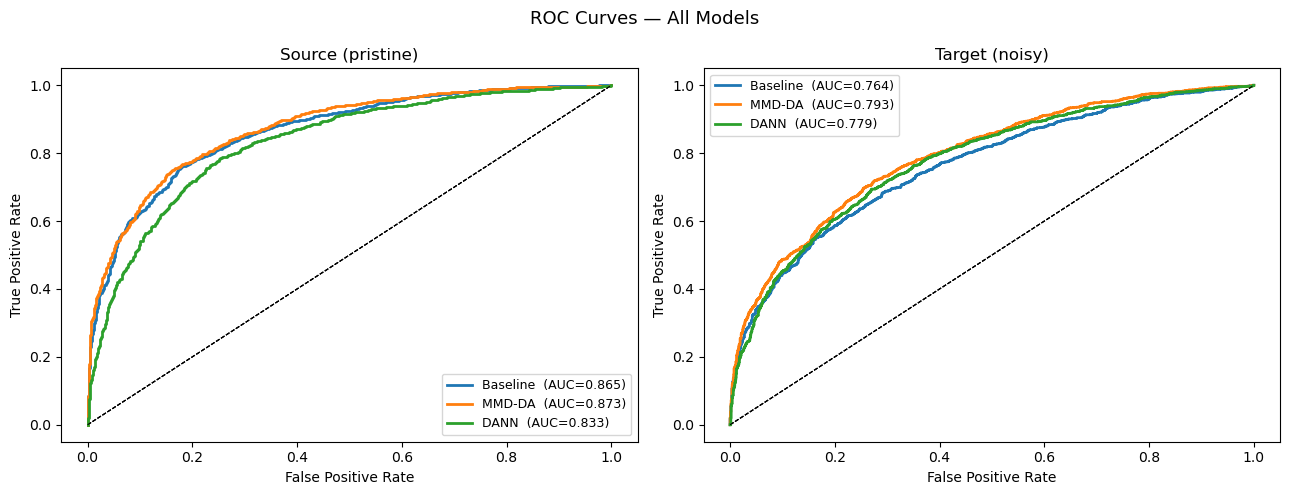


Model                   Src Acc    Tgt Acc    Src AUC    Tgt AUC
------------------------------------------------------------
Baseline                 76.71%     64.17%      0.865      0.764
MMD-DA                   78.85%     71.98%      0.873      0.793
DANN                     75.77%     70.65%      0.833      0.779


In [46]:
# Combined ROC curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC Curves — All Models', fontsize=13)
for (name, s_t, s_prob, t_t, t_prob) in [
    ('Baseline',  res_ce_s_t,  res_ce_s_prob,  res_ce_t_t,  res_ce_t_prob),
    ('MMD-DA',    res_mmd_s_t, res_mmd_s_prob, res_mmd_t_t, res_mmd_t_prob),
    ('DANN',      res_d_s_t,   res_d_s_prob,   res_d_t_t,   res_d_t_prob),
]:
    plot_roc_curve(s_t, s_prob, name, ax1)
    plot_roc_curve(t_t, t_prob, name, ax2)
ax1.set_title('Source (pristine)')
ax2.set_title('Target (noisy)')
plt.tight_layout(); plt.show()

# Summary table
print(f'\n{"Model":<20} {"Src Acc":>10} {"Tgt Acc":>10} {"Src AUC":>10} {"Tgt AUC":>10}')
print('-' * 60)
for (name, model) in [('Baseline', CE_model), ('MMD-DA', MMD_model), ('DANN', DANN_model)]:
    ys_t, ys_p, ys_prob, _ = get_predictions(model, source_test_loader, device)
    yt_t, yt_p, yt_prob, _ = get_predictions(model, target_test_loader, device)
    src_acc = 100*(ys_p==ys_t).mean()
    tgt_acc = 100*(yt_p==yt_t).mean()
    src_auc = auc(*roc_curve(ys_t, ys_prob)[:2])
    tgt_auc = auc(*roc_curve(yt_t, yt_prob)[:2])
    print(f'{name:<20} {src_acc:>9.2f}% {tgt_acc:>9.2f}% {src_auc:>10.3f} {tgt_auc:>10.3f}')

### Final Questions

- Which method closed the most of the source–target gap? Were you surprised?
- Look at the source accuracy across all three models. Did DA hurt source performance? Is a small drop acceptable?
- The t-SNE shows the latent space *after* training. What would you want to see in an ideal DA result — and how close did you get?

## 9. Extensions

Here are some directions to explore on your own:

**Data**
- Swap the domains: train on the noisy images and evaluate on pristine. Does adaptation help equally in both directions, or is one direction harder?
- **Galaxy morphology classification**: instead of merger detection, try multi-class morphology classification using the [Galaxy Zoo Evo Dataset](https://zenodo.org/records/15215272) (click `galaxy_dataset.zip` — you will need to log in with a GitHub or ORCID account; the dataset is 2.35 GB). It contains SDSS and DESI imaging of the same galaxies, making a natural source–target pair. Classes are: barred_spiral (0), edge_on_disk (1), featured_without_bar_or_spiral (2), smooth_cigar (3), smooth_round (4), unbarred_spiral (5). Recall that images are typically normalized to be in the range [-1,1] for gradient stabilitiy during training. You can do this via [z-score normalization](https://en.wikipedia.org/wiki/Standard_score).

**Model architecture**
- Make the CNN deeper — add residual (skip) connections, more filters, or an extra convolutional block. Does a more expressive feature extractor improve domain alignment?
- Try a pre-trained backbone (e.g. a small ResNet fine-tuned from ImageNet weights). Transfer learning from natural images often helps even for astronomical data.

**Training**
- Add a learning rate scheduler (`CosineAnnealingLR` or `ReduceLROnPlateau`) and observe its effect on convergence and the source–target gap.
- Test increasing or decreasing DA loss weight $\lambda$. What happens when you do this? Can the optimal weight be learned?
- For DANN, gradually increase $\lambda$ during training using the schedule from the original paper: $\lambda = \frac{2}{1+e^{-10p}} - 1$, where $p$ is the fraction of training completed. This stabilises early training when the feature extractor is still random.

**MMD**
- Experiment with different kernel bandwidth sets in `MMDLoss`. What happens with only one $\sigma$ vs. many? Can you find a better set for galaxy images?
- Implement a **median heuristic** to set $\sigma$ automatically from the pairwise distances in each mini-batch.
- Compare with the [`geomloss`](https://www.kernel-operations.io/geomloss/) energy distance (`SamplesLoss('energy', p=2)`) — does it align the latent space differently? Try other distances included in that package, and learn about their pros and cons.

**Evaluation & visualisation**
- Monitor target validation accuracy *during* training (without using it for model selection) to see how domain alignment evolves epoch by epoch.
- Monitor target validation accuracy *during* training (without using it for model selection) to see how domain alignment evolves epoch by epoch.
- Try Try [**UMAP**](https://umap-learn.readthedocs.io/en/latest/) as an alternative to t-SNE — it is faster and often preserves global cluster structure better for high-dimensional latent spaces.

**Other DA methods**
- Implement **CORAL** (Correlation Alignment): minimise the Frobenius norm between source and target second-order feature statistics — much simpler than MMD or DANN and often surprisingly competitive.

For context on what is achievable with more sophisticated models, see [Ciprijanovic et al. (2021)](https://arxiv.org/pdf/2103.01373) which applies DA to galaxy merger detection. Also check out [Pandya et al. (2025)](https://arxiv.org/pdf/2501.14048) for galaxy morphology classification with GalaxyZoo Evo dataset.

Happy coding!